# Apple Inc. (AAPL) - 5 Year Stock Market Analysis

## Project Overview
This analysis examines Apple Inc.'s stock performance over a 5-year period using daily OHLCV (Open, High, Low, Close, Volume) data. The objective is to identify key trends, volatility patterns, seasonality effects, and relationships between price movements and trading volume through rigorous statistical analysis.

**Questions this analysis answers:**
1. How has AAPL's price performed over 5 years, and how has its risk (volatility) profile changed?
2. Is trading volume related to price level or daily price direction?
3. Are there calendar patterns in returns (by month or by weekday)?

**Data Source:** Yahoo Finance (yfinance)  
**Time Period:** 5 years of daily trading data  
**Analysis Type:** Descriptive & Statistical Analysis

## Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## Data Acquisition & Preparation

In [2]:
# Download 5 years of AAPL daily data
aapl = yf.download("AAPL", period="5y", interval="1d", auto_adjust=False)

# Flatten MultiIndex columns if present
if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.map(lambda x: x[0] if isinstance(x, tuple) else x)

# Reset index and prepare data
aapl.reset_index(inplace=True)
aapl['Year'] = aapl['Date'].dt.year
aapl['Month'] = aapl['Date'].dt.month
aapl['Weekday'] = pd.to_datetime(aapl['Date']).dt.day_name()
aapl.set_index('Date', inplace=True)
aapl = aapl.round(2)
aapl.rename(columns={'Adj Close': 'Adj_Close'}, inplace=True)

print(f"Dataset loaded: {aapl.shape[0]} trading days from {aapl.index[0].date()} to {aapl.index[-1].date()}")
print(f"Missing values: {aapl.isnull().sum().sum()}")
print(f"Duplicate rows: {aapl.duplicated().sum()}")
display(aapl.head())

[*********************100%***********************]  1 of 1 completed

Dataset loaded: 1254 trading days from 2021-08-06 to 2026-08-05
Missing values: 0
Duplicate rows: 0


,Adj_Close,Close,High,Low,Open,Volume,Year,Month,Weekday
Date,,,,,,,,,
2021-08-06,142.66,146.14,147.11,145.63,146.35,54126800,2021,8,Friday
2021-08-09,142.61,146.09,146.70,145.52,146.20,48908700,2021,8,Monday
2021-08-10,142.14,145.60,147.71,145.30,146.44,69023100,2021,8,Tuesday
2021-08-11,142.39,145.86,146.72,145.53,146.05,48493500,2021,8,Wednesday
2021-08-12,145.35,148.89,149.05,145.84,146.19,72282600,2021,8,Thursday


## Feature Engineering

In [3]:
# Daily price features
aapl['Daily_Range'] = aapl['High'] - aapl['Low']
aapl['Daily_Change'] = aapl['Close'] - aapl['Open']
aapl['Pct_Change'] = aapl['Close'].pct_change() * 100
aapl['Range_Pct'] = (aapl['Daily_Range'] / aapl['Open']) * 100

# Moving average (trend)
aapl['MA_30'] = aapl['Close'].rolling(window=30).mean()

# Volatility: rolling std of DAILY % RETURNS (comparable across price levels)
aapl['Volatility_30'] = aapl['Pct_Change'].rolling(window=30).std()

print("Features created: Daily_Range, Daily_Change, Pct_Change, Range_Pct, MA_30, Volatility_30")

Features created: Daily_Range, Daily_Change, Pct_Change, Range_Pct, MA_30, Volatility_30


**Features Created:** Daily price ranges, daily percentage returns, a 30-day moving average for trend, and 30-day rolling volatility computed on percentage returns (not raw prices) so it stays comparable as the price level changes.

## Descriptive Statistics

In [4]:
# Overall dataset statistics
overall_stats = aapl[['Close', 'Volume', 'Daily_Change', 'Volatility_30']].describe().round(2)
print("[OVERALL SUMMARY]")
display(overall_stats)

# Yearly performance
yearly_summary = aapl.groupby('Year').agg({
    'Close': ['count', 'mean', 'std', 'min', 'max'],
    'Volume': 'mean',
    'Volatility_30': 'mean'
}).round(2)
yearly_summary.columns = ['_'.join(col).strip() for col in yearly_summary.columns.values]
print("\n[YEARLY SUMMARY]")
display(yearly_summary)

[OVERALL SUMMARY]


,Close,Volume,Daily_Change,Volatility_30
count,1254.00,1254.00,1254.00,1224.00
mean,199.20,64705964.02,0.22,1.65
std,46.65,28574725.18,2.94,0.63
min,125.02,17910600.00,-14.28,0.64
25%,162.90,45514200.00,-1.29,1.26
50%,187.94,56335750.00,0.21,1.54
75%,230.39,76397950.00,1.73,1.88
max,340.08,318679900.00,26.90,4.40



[YEARLY SUMMARY]


,Close_count,Close_mean,Close_std,Close_min,Close_max,Volume_mean,Volatility_30_mean
Year,,,,,,,
2021,103,154.39,11.36,139.14,180.33,84755535.92,1.38
2022,251,154.84,13.06,126.04,182.01,87910376.49,2.20
2023,250,172.55,17.33,125.02,198.11,59223547.60,1.32
2024,252,207.21,25.50,165.00,259.02,57106779.76,1.39
2025,250,232.24,26.47,172.42,286.19,54175778.40,1.84
2026,148,281.24,25.34,246.63,340.08,51386582.28,1.55


**Key Insight:** Apple's average closing price rose 82% from $154 (2021) to $281 (2026), yet neither volume nor risk rose with it. Average daily volume fell steadily from ~85M shares (2021) to ~51M (2026), a decline of roughly 39%. Volatility, now measured on percentage returns, shows no upward trend at all: 2022 was the most volatile year (2.20% daily), 2023-2024 were the calmest (~1.3-1.4%), and 2026 sits near the 5-year average (1.55% vs 1.65% overall). The price advance was steady rather than increasingly turbulent.

## Distribution Analysis

In [5]:
# Test normality of daily returns
pct_change_clean = aapl['Pct_Change'].dropna()
stat_normaltest, p_normaltest = stats.normaltest(pct_change_clean)

skewness = pct_change_clean.skew()
kurtosis = pct_change_clean.kurtosis()

print(f"Normality Test p-value: {p_normaltest:.6f}")
print(f"Skewness: {skewness:.4f} (negative = left tail)")
print(f"Kurtosis: {kurtosis:.4f} (>0 = fat tails)")

Normality Test p-value: 0.000000
Skewness: 0.3765 (negative = left tail)
Kurtosis: 6.6363 (>0 = fat tails)


**Key Insight:** Daily returns are NOT normally distributed (p < 0.001). Skewness is mildly positive (+0.38): the distribution is pulled slightly rightward by occasional outsized up-days rather than showing the left tail often assumed for equities. The more important feature is kurtosis of 6.64, indicating pronounced fat tails — extreme daily moves occur far more often than a normal distribution predicts. Any risk measure that assumes normality (such as standard Value-at-Risk) will understate the likelihood of large moves in both directions.

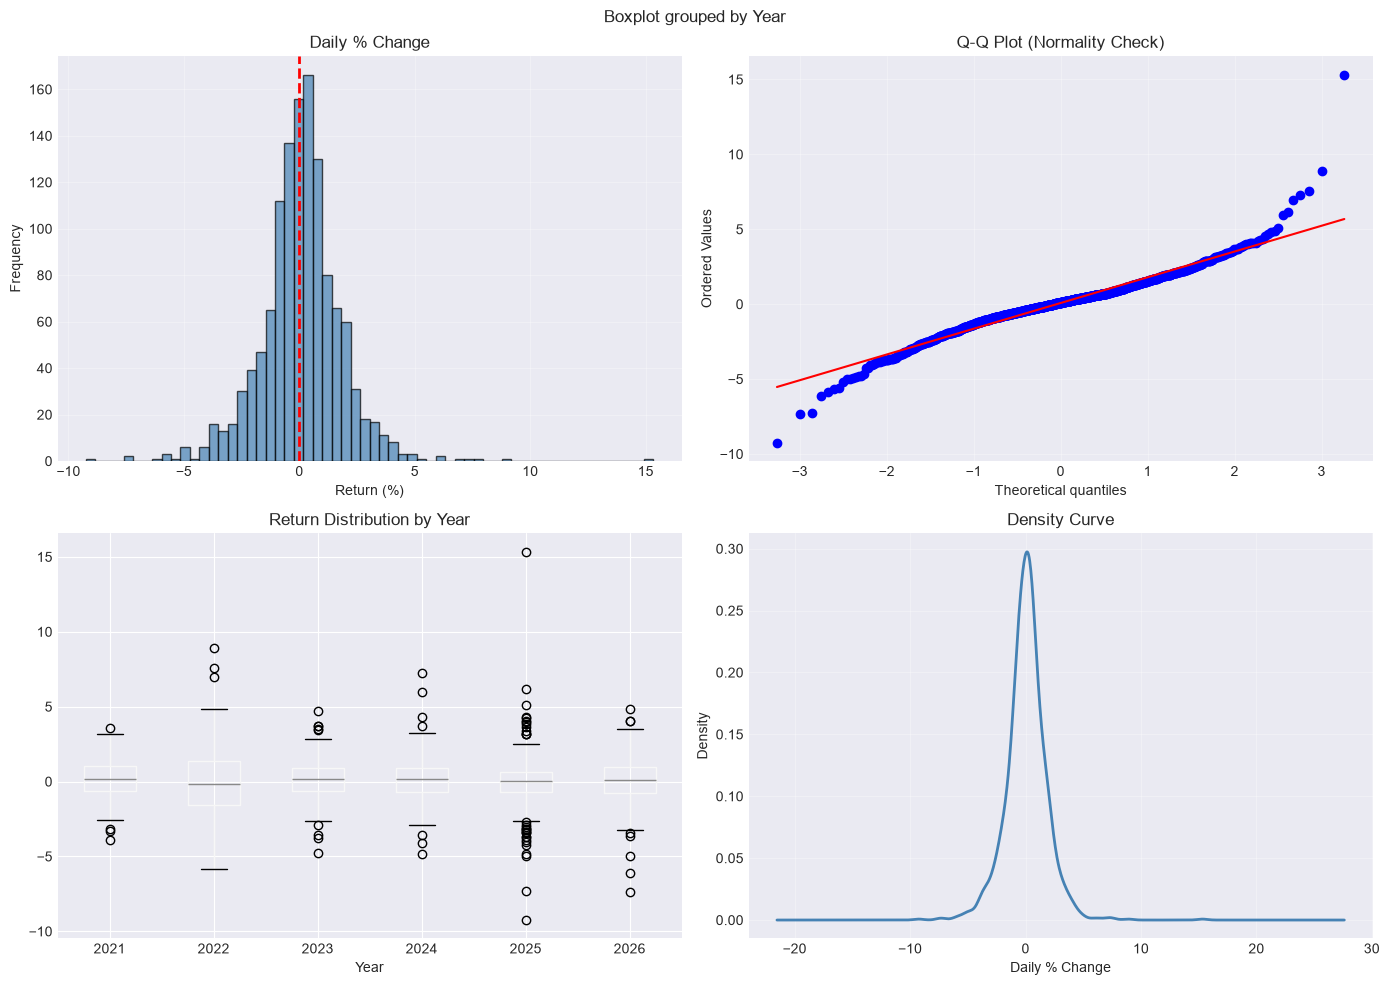

In [6]:
# Visualize return distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Daily Return Distribution Analysis', fontsize=14, fontweight='bold')

axes[0, 0].hist(pct_change_clean, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Daily % Change')
axes[0, 0].set_xlabel('Return (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

stats.probplot(pct_change_clean, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)')
axes[0, 1].grid(alpha=0.3)

aapl.boxplot(column='Pct_Change', by='Year', ax=axes[1, 0])
axes[1, 0].set_title('Return Distribution by Year')
axes[1, 0].set_xlabel('Year')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

pct_change_clean.plot(kind='density', ax=axes[1, 1], color='steelblue', linewidth=2)
axes[1, 1].set_title('Density Curve')
axes[1, 1].set_xlabel('Daily % Change')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Analysis

In [7]:
# Build correlation matrix
corr_cols = ['Close', 'Volume', 'Daily_Change', 'Pct_Change', 'Volatility_30', 'Daily_Range']
correlation_matrix = aapl[corr_cols].corr().round(3)

print("[CORRELATION MATRIX]")
display(correlation_matrix)

price_volume_corr = aapl['Pct_Change'].corr(aapl['Volume'])
volatility_range_corr = aapl['Volatility_30'].corr(aapl['Daily_Range'])

print(f"\nPrice Change vs Volume: {price_volume_corr:.4f}")
print(f"Volatility vs Daily Range: {volatility_range_corr:.4f}")

[CORRELATION MATRIX]


,Close,Volume,Daily_Change,Pct_Change,Volatility_30,Daily_Range
Close,1.00,-0.40,0.06,0.05,-0.22,0.34
Volume,-0.40,1.00,0.05,0.01,0.27,0.37
Daily_Change,0.06,0.05,1.00,0.77,0.04,0.06
Pct_Change,0.05,0.01,0.77,1.00,0.00,-0.00
Volatility_30,-0.22,0.27,0.04,0.00,1.00,0.27
Daily_Range,0.34,0.37,0.06,-0.00,0.27,1.00



Price Change vs Volume: 0.0126
Volatility vs Daily Range: 0.2654


**Key Insight:** Daily price change and volume are essentially uncorrelated (0.01), so volume carries no information about daily direction. The stronger relationships are structural: Close vs Volume at -0.40 reflects the long-run pattern of volume declining while the price climbed, and Volatility vs Volume at +0.27 shows trading activity picks up modestly during turbulent stretches. Volatility vs Daily_Range correlation is only 0.27, so the dollar price range is a weak proxy for return volatility. The 0.77 correlation between Daily_Change and Pct_Change is expected, as both measure the same day's move in different units.

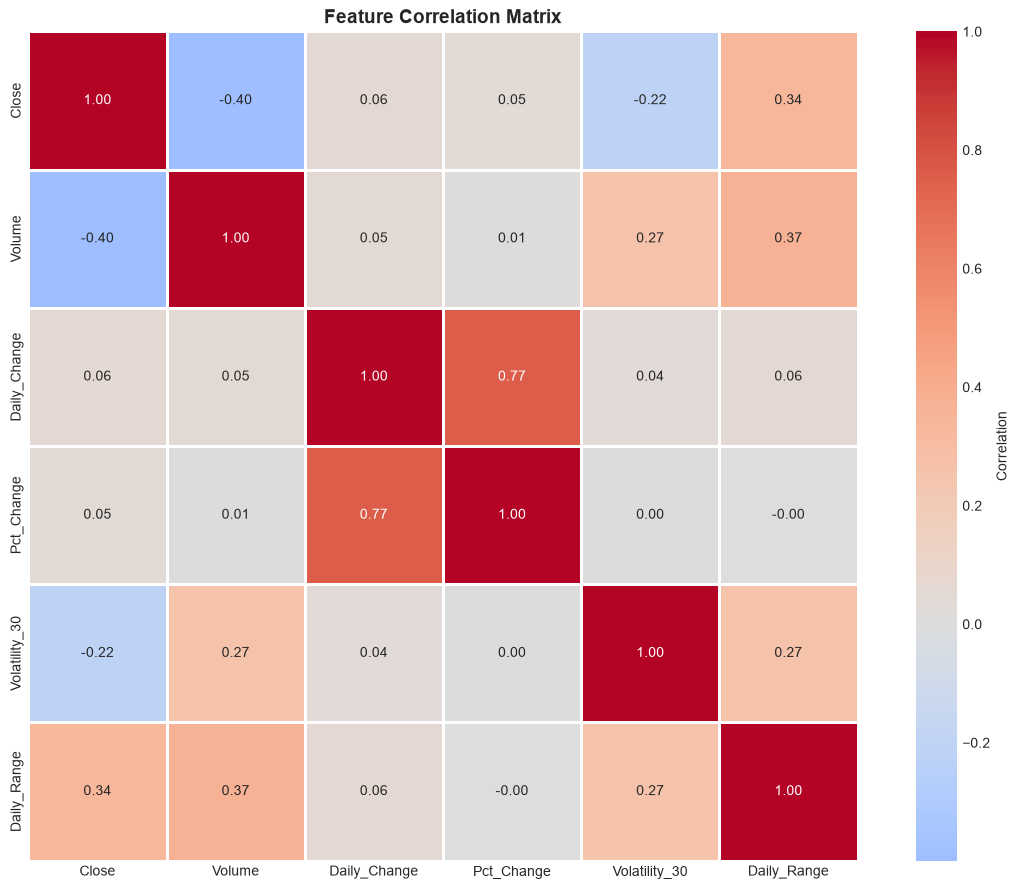

In [8]:
# Visualize correlations
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=2, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Volume-Price Relationship

In [9]:
# Opening price level vs volume — compared WITHIN each year to remove time-trend bias
# (prices rose and volume fell over the sample, so full-period averages would confound the two)
yearly_avg = aapl.groupby('Year')[['Open', 'Volume']].transform('mean')

low_open_high_vol = aapl[(aapl['Open'] < yearly_avg['Open']) & (aapl['Volume'] > yearly_avg['Volume'])]
high_open_high_vol = aapl[(aapl['Open'] > yearly_avg['Open']) & (aapl['Volume'] > yearly_avg['Volume'])]

print("[OPENING PRICE EFFECT ON VOLUME - vs same-year averages]")
print(f"Days: LOW open + HIGH volume: {len(low_open_high_vol)}")
print(f"Days: HIGH open + HIGH volume: {len(high_open_high_vol)}")
print(f"Ratio: {len(low_open_high_vol) / len(high_open_high_vol):.2f}x")

[OPENING PRICE EFFECT ON VOLUME - vs same-year averages]
Days: LOW open + HIGH volume: 241
Days: HIGH open + HIGH volume: 210
Ratio: 1.15x


**Key Insight:** Once opening price and volume are compared against same-year averages, the apparent "low price attracts volume" effect nearly disappears: 241 low-open/high-volume days vs 210 high-open/high-volume days, a ratio of just 1.15x. The naive full-period comparison had suggested a 4.8x ratio, but that was an artifact of time structure (early years combined lower prices with higher volume). After controlling for year, there is only a slight tilt toward higher volume on below-average-price days — not meaningful evidence of dip-buying behavior.

In [10]:
# Analyze price direction impact on volume
up_days = aapl[aapl['Daily_Change'] > 0]
down_days = aapl[aapl['Daily_Change'] < 0]

avg_vol_up = up_days['Volume'].mean()
avg_vol_down = down_days['Volume'].mean()

t_stat, p_value = ttest_ind(up_days['Volume'], down_days['Volume'])

print(f"\n[PRICE DIRECTION IMPACT ON VOLUME]")
print(f"Avg Volume on UP days: {avg_vol_up/1e6:.1f}M shares")
print(f"Avg Volume on DOWN days: {avg_vol_down/1e6:.1f}M shares")
print(f"Difference: {((avg_vol_down/avg_vol_up - 1)*100):.2f}%")
print(f"\nT-Test p-value: {p_value:.4f}")
print(f"Statistically Significant: {'YES (p<0.05)' if p_value < 0.05 else 'NO (p>=0.05)'}")


[PRICE DIRECTION IMPACT ON VOLUME]
Avg Volume on UP days: 63.9M shares
Avg Volume on DOWN days: 65.7M shares
Difference: 2.82%

T-Test p-value: 0.2674
Statistically Significant: NO (p>=0.05)


**Key Insight:** Average volume on up days (63.9M shares) is nearly identical to down days (65.7M). The 2.8% difference is not statistically significant (t-test p = 0.267), so daily price direction does not drive trading volume. Combined with the near-zero price-change/volume correlation, this points to volume being determined by broader market activity (earnings dates, index events, macro news) rather than by whether Apple closed up or down.

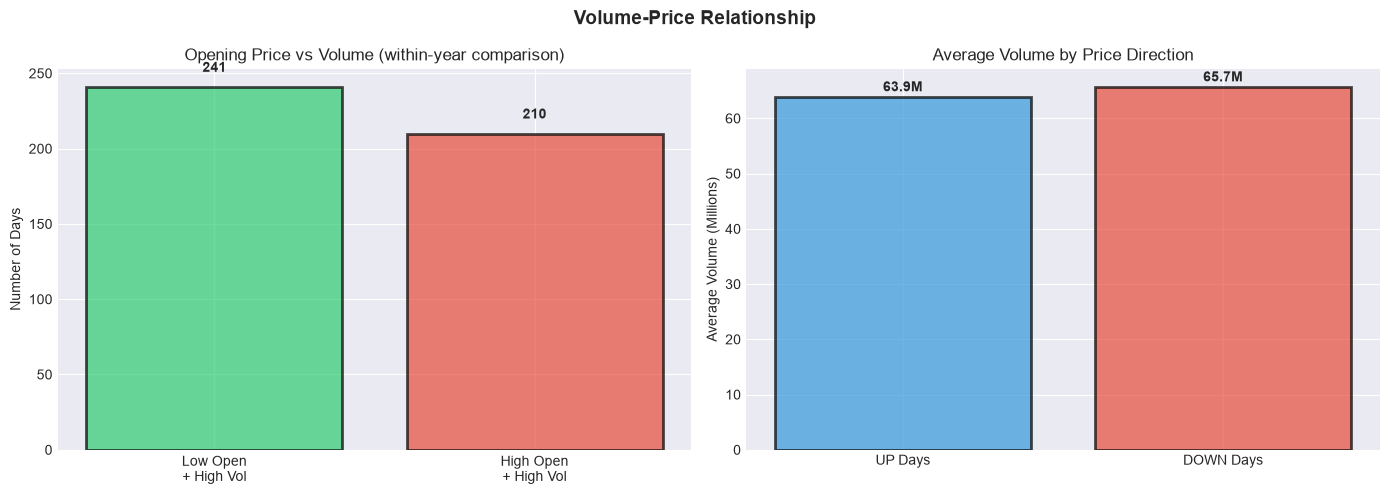

In [11]:
# Visualize volume patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Volume-Price Relationship', fontsize=14, fontweight='bold')

axes[0].bar(['Low Open\n+ High Vol', 'High Open\n+ High Vol'],
            [len(low_open_high_vol), len(high_open_high_vol)],
            color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Days')
axes[0].set_title('Opening Price vs Volume (within-year comparison)')
for i, v in enumerate([len(low_open_high_vol), len(high_open_high_vol)]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(['UP Days', 'DOWN Days'],
            [avg_vol_up/1e6, avg_vol_down/1e6],
            color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Average Volume (Millions)')
axes[1].set_title('Average Volume by Price Direction')
for i, v in enumerate([avg_vol_up/1e6, avg_vol_down/1e6]):
    axes[1].text(i, v + 1, f'{v:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Volatility Analysis

In [12]:
# Analyze volatility trends
volatility_by_year = aapl.groupby('Year')['Volatility_30'].agg([
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2)

print("[VOLATILITY BY YEAR]")
display(volatility_by_year)

high_vol_threshold = aapl['Volatility_30'].quantile(0.75)
low_vol_threshold = aapl['Volatility_30'].quantile(0.25)
high_vol_days = len(aapl[aapl['Volatility_30'] > high_vol_threshold])

print(f"\nHigh Volatility Days (top 25%): {high_vol_days}")

[VOLATILITY BY YEAR]


,Mean,Std,Min,Max
Year,,,,
2021,1.38,0.26,0.98,1.90
2022,2.20,0.45,1.52,3.12
2023,1.32,0.32,0.79,2.17
2024,1.39,0.29,0.81,2.06
2025,1.84,0.94,0.82,4.40
2026,1.55,0.41,0.64,2.56



High Volatility Days (top 25%): 306


**Key Insight:** Measured on percentage returns, Apple's volatility is episodic rather than trending. 2022 was the most volatile year (mean 2.20% daily), 2023 and 2024 were the calmest (~1.3-1.4%), 2025 saw a sharp spike (single highest reading of 4.40%, the peak of the whole sample), and 2026 has settled back near the long-run average (1.55% vs 1.65% overall). This is a notably different picture from a dollar-based volatility measure, which would suggest steadily rising risk — that apparent rise is a price-level artifact, not a change in the stock's risk profile.

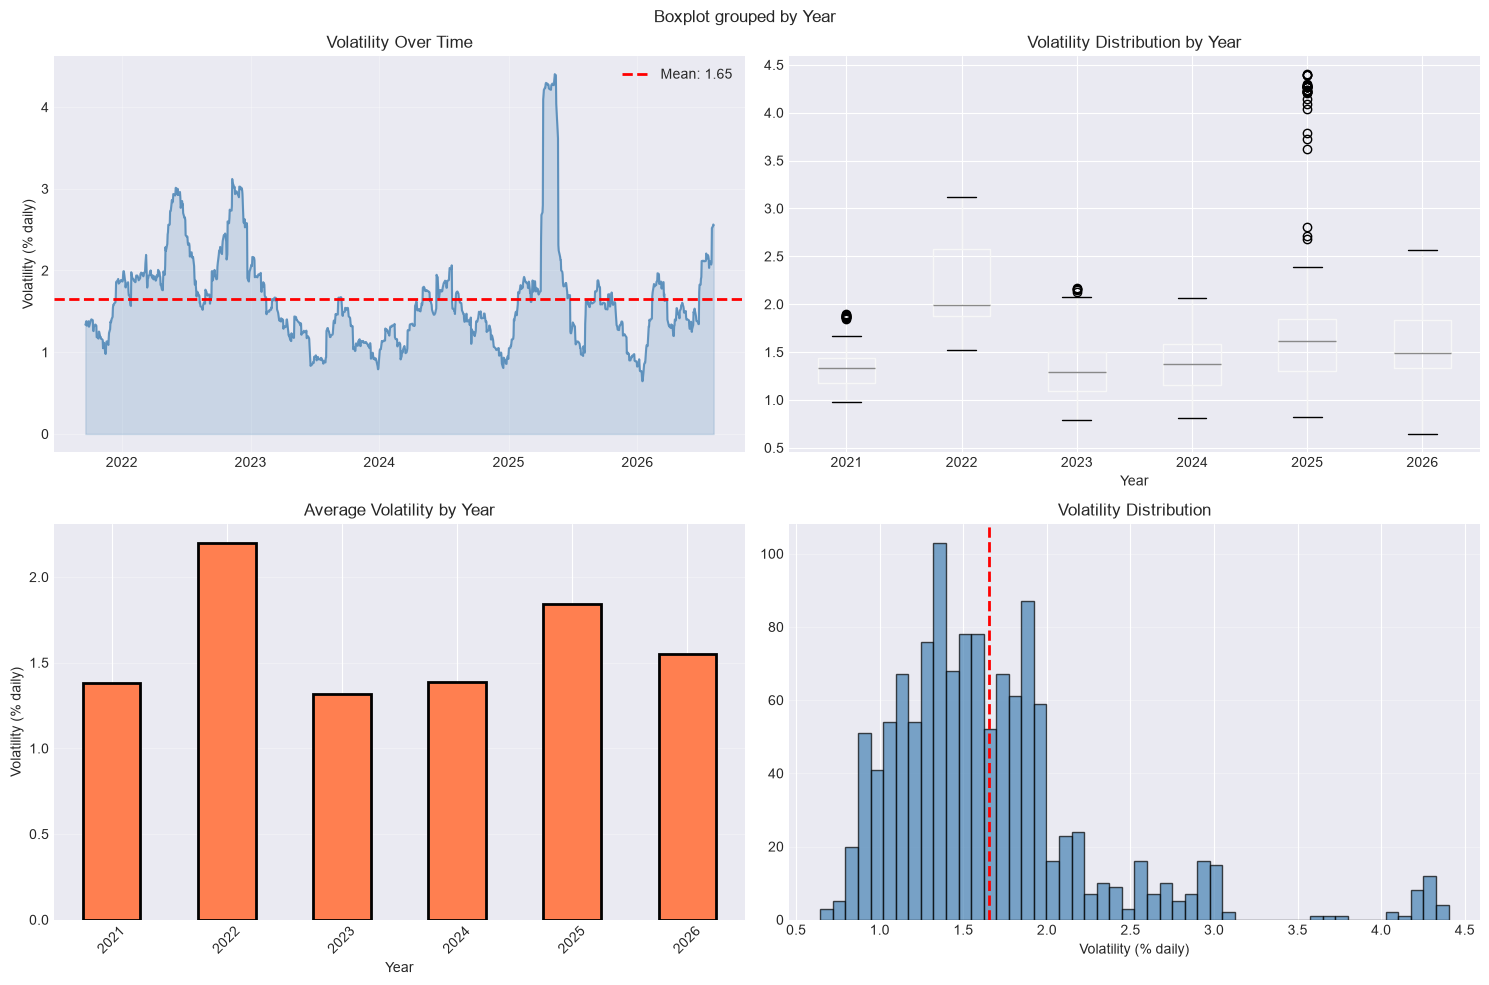

In [13]:
# Visualize volatility trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Volatility Analysis (30-Day Rolling Std of Daily % Returns)', fontsize=14, fontweight='bold')

axes[0, 0].plot(aapl.index, aapl['Volatility_30'], color='steelblue', linewidth=1.5, alpha=0.8)
axes[0, 0].fill_between(aapl.index, aapl['Volatility_30'], alpha=0.2, color='steelblue')
axes[0, 0].axhline(aapl['Volatility_30'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {aapl["Volatility_30"].mean():.2f}')
axes[0, 0].set_title('Volatility Over Time')
axes[0, 0].set_ylabel('Volatility (% daily)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

aapl.boxplot(column='Volatility_30', by='Year', ax=axes[0, 1])
axes[0, 1].set_title('Volatility Distribution by Year')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

volatility_by_year['Mean'].plot(kind='bar', ax=axes[1, 0], color='coral', edgecolor='black', linewidth=2)
axes[1, 0].set_title('Average Volatility by Year')
axes[1, 0].set_ylabel('Volatility (% daily)')
axes[1, 0].set_xticklabels(volatility_by_year.index, rotation=45)
axes[1, 0].grid(alpha=0.3, axis='y')

axes[1, 1].hist(aapl['Volatility_30'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].axvline(aapl['Volatility_30'].mean(), color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Volatility Distribution')
axes[1, 1].set_xlabel('Volatility (% daily)')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Price Trends & Seasonality

In [14]:
# Calculate long-term performance
yearly_close = aapl.groupby('Year')['Close'].agg(['first', 'last', 'min', 'max', 'mean'])
yearly_close['Return_%'] = ((yearly_close['last'] - yearly_close['first']) / yearly_close['first'] * 100).round(2)

start_date, end_date = aapl.index[0], aapl.index[-1]
n_years = (end_date - start_date).days / 365.25
total_return = ((aapl['Close'].iloc[-1] - aapl['Close'].iloc[0]) / aapl['Close'].iloc[0] * 100)
cagr = ((aapl['Close'].iloc[-1] / aapl['Close'].iloc[0]) ** (1 / n_years) - 1) * 100

print(f"[{n_years:.1f}-YEAR PERFORMANCE]")
print(f"Start Price ({start_date.strftime('%b %Y')}): ${aapl['Close'].iloc[0]:.2f}")
print(f"End Price ({end_date.strftime('%b %Y')}): ${aapl['Close'].iloc[-1]:.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")

print("\n[YEARLY RETURNS]")
display(yearly_close[['Return_%']])

[5.0-YEAR PERFORMANCE]
Start Price (Aug 2021): $146.14
End Price (Aug 2026): $311.00
Total Return: 112.81%
CAGR: 16.32%

[YEARLY RETURNS]


,Return_%
Year,
2021,21.51
2022,-28.61
2023,53.94
2024,34.90
2025,11.49
2026,14.76


**Key Insight:** Apple returned 112.8% over the 5 years (16.3% CAGR), climbing from $146 (Aug 2021) to $311 (Aug 2026), but the path was uneven. Every calendar year was positive except 2022, which fell -28.6%. The recovery that followed was strong (+53.9% in 2023, +34.9% in 2024) before gains moderated (+11.5% in 2025, +14.8% in 2026 to date). The 2022 drawdown is the key caveat to the headline number: capturing the full 5-year return required holding through a year in which the stock lost over a quarter of its value.

In [15]:
# Seasonality: compute each year-month's return, then average across years
monthly_close = aapl['Close'].resample('ME').last()
monthly_ret = (monthly_close.pct_change().dropna() * 100)
avg_monthly = monthly_ret.groupby(monthly_ret.index.month).mean().round(2)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("[AVERAGE MONTHLY RETURN (%) - averaged across years]")
for month, ret in avg_monthly.items():
    n = (monthly_ret.index.month == month).sum()
    print(f"{month_names[month-1]:>3}: {ret:>6.2f}%  (n={n} years)")

[AVERAGE MONTHLY RETURN (%) - averaged across years]
Jan:  -1.01%  (n=5 years)
Feb:  -0.21%  (n=5 years)
Mar:   0.08%  (n=5 years)
Apr:  -0.98%  (n=5 years)
May:   4.25%  (n=5 years)
Jun:   1.14%  (n=5 years)
Jul:   6.70%  (n=5 years)
Aug:   1.60%  (n=5 years)
Sep:  -3.27%  (n=5 years)
Oct:   3.94%  (n=5 years)
Nov:   5.26%  (n=5 years)
Dec:  -0.09%  (n=5 years)


**Key Insight:** Averaged across the 5 years, July (+6.7%), November (+5.3%), May (+4.3%), and October (+3.9%) were the strongest months, while September was clearly the weakest (-3.3%), with January and April mildly negative (~ -1%). A summer-strength / September-weakness pattern is visible, but each monthly average rests on only 5 observations, so a single unusual year can move these figures materially. Treat this as a descriptive pattern in this sample, not a reliable timing signal.

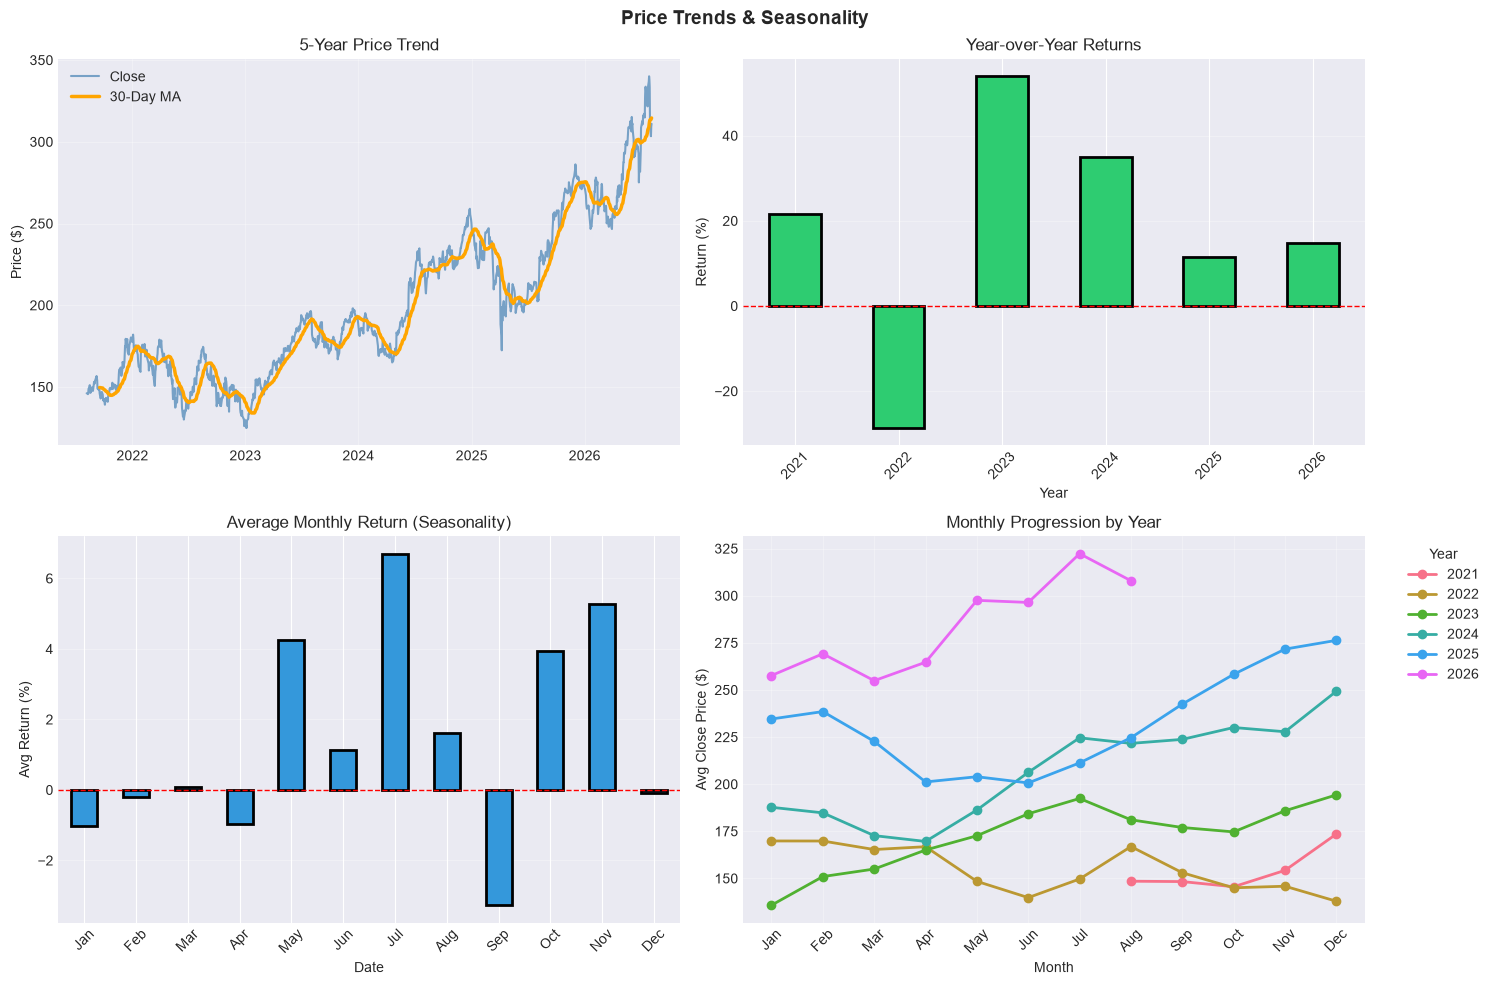

In [16]:
# Visualize trends and seasonality
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Price Trends & Seasonality', fontsize=14, fontweight='bold')

axes[0, 0].plot(aapl.index, aapl['Close'], color='steelblue', linewidth=1.5, label='Close', alpha=0.7)
axes[0, 0].plot(aapl.index, aapl['MA_30'], color='orange', linewidth=2.5, label='30-Day MA')
axes[0, 0].set_title('5-Year Price Trend')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

yearly_close['Return_%'].plot(kind='bar', ax=axes[0, 1], color='#2ecc71',
                               edgecolor='black', linewidth=2)
axes[0, 1].set_title('Year-over-Year Returns')
axes[0, 1].set_ylabel('Return (%)')
axes[0, 1].set_xticklabels(yearly_close.index, rotation=45)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].grid(alpha=0.3, axis='y')

avg_monthly.plot(kind='bar', ax=axes[1, 0], color='#3498db',
                 edgecolor='black', linewidth=2)
axes[1, 0].set_title('Average Monthly Return (Seasonality)')
axes[1, 0].set_ylabel('Avg Return (%)')
axes[1, 0].set_xticklabels([month_names[m-1] for m in avg_monthly.index], rotation=45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].grid(alpha=0.3, axis='y')

monthly_by_year = aapl.groupby(['Year', 'Month'])['Close'].mean().unstack('Year')
monthly_by_year.plot(ax=axes[1, 1], marker='o', linewidth=2)
axes[1, 1].set_title('Monthly Progression by Year')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Avg Close Price ($)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(month_names, rotation=45)
axes[1, 1].legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Weekday Effect

[DAILY RETURN BY WEEKDAY]


,Mean_%,Std_%,Days
Weekday,,,
Monday,0.11,1.65,234
Tuesday,0.12,1.56,260
Wednesday,0.16,1.82,258
Thursday,-0.09,1.90,250
Friday,0.08,1.89,251


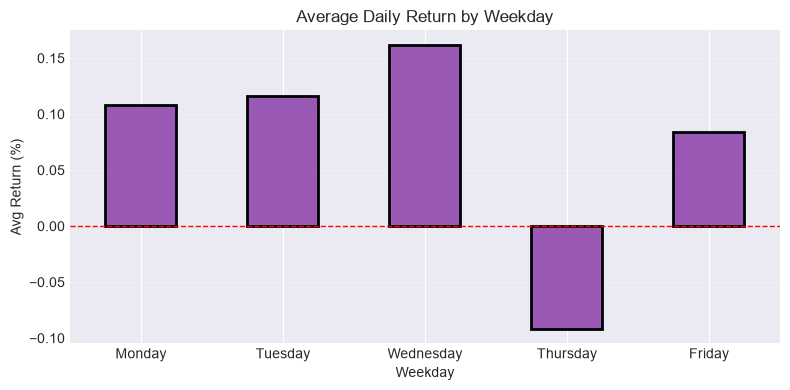

In [17]:
# Average daily return by weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday_stats = aapl.groupby('Weekday')['Pct_Change'].agg(
    [('Mean_%', 'mean'), ('Std_%', 'std'), ('Days', 'count')]
).reindex(weekday_order).round(3)

print("[DAILY RETURN BY WEEKDAY]")
display(weekday_stats)

fig, ax = plt.subplots(figsize=(8, 4))
weekday_stats['Mean_%'].plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black', linewidth=2)
ax.set_title('Average Daily Return by Weekday')
ax.set_ylabel('Avg Return (%)')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key Insight:** There is no meaningful weekday effect. Average daily returns range from -0.09% (Thursday) to +0.16% (Wednesday), differences that are tiny compared with the typical daily swing (standard deviation of 1.6-1.9% on every weekday). Day-to-day noise dwarfs any day-of-week pattern, so the weekday of a trade carries no informational value in this sample.

## Executive Summary & Strategic Recommendations

### Key Findings

**1. Price performance & risk profile**
- Apple returned 112.8% (16.3% CAGR) from Aug 2021 ($146) to Aug 2026 ($311)
- Every calendar year was positive except 2022 (-28.6%); the strongest years were 2023 (+53.9%) and 2024 (+34.9%)
- Volatility is episodic, not trending: 2022 was the most turbulent year (2.20% daily), 2023-2024 the calmest, and 2026 sits near the 5-year average — the stock's risk profile has not deteriorated as the price climbed
- Daily returns are non-normal (p < 0.001) with heavy fat tails (kurtosis 6.64), so normality-based risk measures understate extreme moves

**2. Volume vs price**
- Volume is unrelated to daily price direction: up days average 63.9M shares vs 65.7M on down days (p = 0.267, not significant)
- The apparent "low prices attract volume" effect vanishes once compared within years (1.15x vs the naive 4.8x), showing it was a time-trend artifact
- The dominant volume story is structural: average daily volume fell ~39% (85M to 51M) while the price more than doubled (Close vs Volume correlation -0.40)

**3. Calendar patterns**
- July (+6.7%), November (+5.3%), May (+4.3%) and October (+3.9%) were the strongest months on average; September the weakest (-3.3%) — but each average rests on just 5 observations
- No weekday effect exists: mean returns by weekday (-0.09% to +0.16%) are trivial against daily noise of 1.6-1.9%

---

### Limitations
- Single ticker over a 5-year window; findings are descriptive, not predictive
- Monthly seasonality averages are based on only 5 observations per month, so they are indicative, not statistically robust
- Past performance does not guarantee future results